In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.options.mode.chained_assignment = None 
pd.options.display.max_columns = None


from scipy import stats
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

In [4]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
import matplotlib.ticker as ticker

fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "16",
    "xtick.labelsize": "16",
    "ytick.labelsize": "16",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images

from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))


In [ ]:
# pop_names = ['notides', 'realistic', 'perfect']
# pop_names = ['realistic', 'perfect']
# pop_names = ['notides', 'perfect']
pop_names = ['realistic']


pop_labels = {'notides': 'LEGACY',
              'realistic': 'K26',
              'perfect': 'PERFECT'}

pop_colors = {'notides': colorPalette['red'],
              'realistic': colorPalette['blue'],
              'perfect': colorPalette['green']}

pop_cmaps = {'notides': 'Reds',
              'realistic': 'Blues',
              'perfect': 'Greens'}

dco_types = ['BBH', 'BHNS', 'BNS']
dco_st = [28, 27, 26]

plot_path = 'pop_plots/'

data_path = 'data_files/'
# if not os.path.exists(plot_path):
#    os.makedirs(plot_path)

In [6]:
pop_dfs = {}
for pop_name in pop_names:
    pop_dfs[pop_name] = pd.read_csv(data_path + pop_name+'_spin_df.csv') 

In [34]:
pop_dfs['realistic'] = pop_dfs['realistic'][pop_dfs['realistic']['BBH'] == True]
pop_dfs['realistic'] = pop_dfs['realistic'][pop_dfs['realistic']['Merges_Hubble_Time'] == True]
pop_dfs['realistic']

,SEED,Mass@ZAMS(1),Mass@ZAMS(2),Metallicity@ZAMS(1),Omega(1),Omega(2),Eccentricity@ZAMS,SemiMajorAxis@ZAMS,CH_on_MS(1),CH_on_MS(2),Mass@DCO(1),Mass@DCO(2),SemiMajorAxis@DCO,Eccentricity@DCO,Stellar_Type(1),Stellar_Type(2),Merges_Hubble_Time,Time@DCO,Coalescence_Time,M_min@DCO,M_max@DCO,Ang_Momentum(SN)_Primary,Ang_Momentum(SN)_Secondary,Ang_Momentum(SN)_Both,MT_Donor_Hist(SN)_Primary,MT_Donor_Hist(SN)_Secondary,Mass(CP)_Primary,Mass(CP)_Secondary,Mass(CP)_Both,Mass(SN)_Primary,Mass(SN)_Secondary,Mass(SN)_Both,Mass_CO_Core@CO(SN)_Primary,Mass_CO_Core@CO(SN)_Secondary,Mass_CO_Core@CO(SN)_Both,Mass_Core@CO(SN)_Primary,Mass_Core@CO(SN)_Secondary,Mass_Core@CO(SN)_Both,Mass_Total@CO(SN)_Primary,Mass_Total@CO(SN)_Secondary,Mass_Total@CO(SN)_Both,Number_of_RLOF(SN)_Primary,Number_of_RLOF(SN)_Secondary,Number_of_RLOF(SN)_Both,Omega(SN)_Primary,Omega(SN)_Secondary,Omega(SN)_Both,Orbital_Period<SN_Primary,Orbital_Period<SN_Secondary,Orbital_Period<SN_Both,RLOF_Primary,RLOF_Secondary,RLOF_Both,Radius_Core@CO(SN)_Primary,Radius_Core@CO(SN)_Secondary,Radius_Core@CO(SN)_Both,Radius_Total@CO(SN)_Primary,Radius_Total@CO(SN)_Secondary,Radius_Total@CO(SN)_Both,SN_Orbit_Inclination_Angle_Primary,SN_Orbit_Inclination_Angle_Secondary,SN_Orbit_Inclination_Angle_Both,SN_Type(SN)_Primary,SN_Type(SN)_Secondary,SN_Type(SN)_Both,SemiMajorAxis<SN_Primary,SemiMajorAxis<SN_Secondary,SemiMajorAxis<SN_Both,Stellar_Type_Prev(SN)_Primary,Stellar_Type_Prev(SN)_Secondary,Stellar_Type_Prev(SN)_Both,Time@SN_Primary,Time@SN_Secondary,Time@SN_Both,Eccentricity<CE_Primary,Eccentricity<CE_Secondary,Eccentricity<CE_Both,Mass(1)<CE_Primary,Mass(1)<CE_Secondary,Mass(1)<CE_Both,Mass(2)<CE_Primary,Mass(2)<CE_Secondary,Mass(2)<CE_Both,SemiMajorAxis<CE_Primary,SemiMajorAxis<CE_Secondary,SemiMajorAxis<CE_Both,Stellar_Type(1)<CE_Primary,Stellar_Type(1)<CE_Secondary,Stellar_Type(1)<CE_Both,Stellar_Type(1)>CE_Primary,Stellar_Type(1)>CE_Secondary,Stellar_Type(1)>CE_Both,Stellar_Type(2)<CE_Primary,Stellar_Type(2)<CE_Secondary,Stellar_Type(2)<CE_Both,Stellar_Type(2)>CE_Primary,Stellar_Type(2)>CE_Secondary,Stellar_Type(2)>CE_Both,Time@CE_Primary,Time@CE_Secondary,Time@CE_Both,CE_Primary,CE_Secondary,CE_Both,BBH,BHNS,BNS,z_form,z_merger,a1,a2,fallback_1,fallback_2,iota1,iota2,chi_eff
3,268128,39.010147,27.517262,0.000431,0.000000e+00,4.215280e+00,0.103031,7.361368,False,False,14.540433,10.477317,0.073187,0.000000e+00,14,14,True,7.870441,2420.265687,10.477317,14.540433,0.000000e+00,2.379390e-05,NaN,NaN,[4],27.168497,14.540433,NaN,14.540433,10.477317,NaN,10.896358,7.753196,NaN,10.896358,7.753196,NaN,14.540433,10.477317,NaN,0.0,1.0,NaN,0.000000e+00,4.215280e+00,NaN,2275.516426,1.445858,NaN,False,True,True,0.000071,0.000071,NaN,1.223451,1.088017,NaN,0.0,0.000000,NaN,1.0,1.0,NaN,11.741693,0.073187,NaN,8.0,8.0,NaN,5.926063,7.870441,NaN,NaN,0.0,NaN,NaN,14.540433,NaN,NaN,26.682713,NaN,NaN,2219.554480,NaN,NaN,14.0,NaN,NaN,14.0,NaN,NaN,4.0,NaN,NaN,7.0,NaN,NaN,7.772374,NaN,False,True,False,True,False,False,8.303270,2.161509,0.000000e+00,3.472333e-04,1.000000,1.000000,0.0,0.000000,1.454197e-04
4,268175,35.970528,31.892628,0.000298,1.627510e+01,1.631355e+04,0.446782,0.417998,False,False,11.720881,20.454058,0.030001,1.110223e-16,14,14,True,8.217540,33.767174,11.720881,20.454058,1.258884e-04,6.851345e-01,NaN,[2],[2],54.247143,11.720881,NaN,11.720621,20.454058,NaN,8.716394,15.607909,NaN,8.716394,15.607909,NaN,11.720621,20.454058,NaN,1.0,1.0,NaN,1.593107e+01,1.631355e+04,NaN,17.355648,0.334615,NaN,True,True,True,0.000071,0.000071,NaN,1.125913,1.450845,NaN,0.0,0.000000,NaN,1.0,1.0,NaN,0.530077,0.030001,NaN,8.0,8.0,NaN,6.301027,8.217540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True,False,False,9.000086,8.517295,1.467983e-03,1.000000e+00,1.000000,1.000000,0.0,0.000000,6.362487e-01
6,268238,48.064860,30.451258,0.004016,8.120247e-12,7.927381e+04,0.060893,3.191490,False,False,15.403003,6.322088,0.048608,2.602534e-01,14,

In [3]:
"""
BBH Population Resampler — Madau-Dickinson Metallicity-Specific SFRD
=====================================================================
Designed for a simulation catalogue with known:
  • m1, m2          – component masses  [M_sun]
  • metallicity     – progenitor metallicity Z  (absolute, e.g. 0.0002–0.05)
  • z_formation     – redshift at which the BBH progenitor formed
  • t_delay         – delay time from star formation to BBH merger  [Gyr]

Pipeline
--------
  1. Evaluate the Madau-Dickinson (2014) SFRD at each system's z_formation.
  2. Weight by the metallicity-specific probability P(Z | z_form) — a
     log-normal whose mean tracks the cosmic enrichment history.
  3. Weight by the comoving volume element dV_c/dz at z_formation (so that
     systems formed in larger volume get proportionally more weight).
  4. Compute the merger redshift z_merger from z_formation + t_delay.
     Systems that merge in the future (z_merger < 0) get weight = 0.
  5. Resample the catalogue to an observed-like population.

References
----------
  Madau & Dickinson 2014, ARA&A 52, 415   (SFRD parametrisation)
  Neijssel et al. 2019, MNRAS 490, 3740   (metallicity-specific SFRD form)
  Planck Collaboration 2018               (cosmology)

Usage
-----
  # Drop-in with your DataFrame:
  from bbh_sfrd_sampler import add_sfrd_weights, resample_population

  df = pd.read_hdf("my_bbhs.h5")        # must have the four columns above
  df = add_sfrd_weights(df)             # adds sfrd_weight, sfrd_weight_norm, z_merger
  df_obs = resample_population(df, n_samples=50_000)
"""


'\nBBH Population Resampler — Madau-Dickinson Metallicity-Specific SFRD\n=====================================================================\nDesigned for a simulation catalogue with known:\n  • m1, m2          – component masses  [M_sun]\n  • metallicity     – progenitor metallicity Z  (absolute, e.g. 0.0002–0.05)\n  • z_formation     – redshift at which the BBH progenitor formed\n  • t_delay         – delay time from star formation to BBH merger  [Gyr]\n\nPipeline\n--------\n  1. Evaluate the Madau-Dickinson (2014) SFRD at each system\'s z_formation.\n  2. Weight by the metallicity-specific probability P(Z | z_form) — a\n     log-normal whose mean tracks the cosmic enrichment history.\n  3. Weight by the comoving volume element dV_c/dz at z_formation (so that\n     systems formed in larger volume get proportionally more weight).\n  4. Compute the merger redshift z_merger from z_formation + t_delay.\n     Systems that merge in the future (z_merger < 0) get weight = 0.\n  5. Resample

In [51]:
# ── Constants ────────────────────────────────────────────────────────────────
Z_SOLAR = 0.0142          # Asplund+2009
T_HUBBLE = cosmo.age(0).to(u.Gyr).value   # ~13.8 Gyr
Z0 = 0.035

# ═══════════════════════════════════════════════════════════════════════════
#  COLUMN NAME MAP  ← edit these to match your DataFrame
# ═══════════════════════════════════════════════════════════════════════════
COLS = dict(
    m1          = "Mass@DCO(1)",           # primary mass   [M_sun]
    m2          = "Mass@DCO(2)",           # secondary mass [M_sun]
    metallicity = "Metallicity@ZAMS(1)",  # absolute Z  (NOT Z/Z_sun, NOT log)
    z_formation = "z_form",  # formation redshift
    t_delay     = "Coalescence_Time",      # delay time  [Gyr]  ← change unit below if needed
    t_delay_unit= "Myr",          # "Gyr" | "Myr" | "yr"
)
# ═══════════════════════════════════════════════════════════════════════════


In [52]:
# ── Cosmology helpers ────────────────────────────────────────────────────────

def lookback_time_gyr(z):
    """Vectorised lookback time [Gyr]."""
    return cosmo.lookback_time(np.atleast_1d(z)).to(u.Gyr).value


def z_from_lookback(t_lb_gyr):
    """
    Invert lookback time → redshift.  Returns 0 if t_lb ≤ 0.
    Vectorised over a numpy array.
    """
    t = np.atleast_1d(t_lb_gyr)
    out = np.zeros_like(t, dtype=float)
    valid = t > 0.0
    for i in np.where(valid)[0]:
        try:
            out[i] = z_at_value(cosmo.lookback_time, t[i] * u.Gyr).value
        except Exception:
            out[i] = np.nan
    return out


def dVc_dz(z):
    """
    Comoving volume element  dV_c/dz  [Mpc^3].
    = 4π * (dV_c/dΩ dz)
    """
    return (cosmo.differential_comoving_volume(z).to(u.Mpc**3 / u.sr).value
            * 4.0 * np.pi)


# ── Madau & Dickinson 2014 SFRD ──────────────────────────────────────────────

def sfrd(z):
    """
    Total SFRD ψ(z) [M_sun yr^-1 Mpc^-3] — MD14 eq. 15., Neijssel+2019 Eq. (6)

        ψ(z) = 0.01 (1+z)^2.77 / [1 + ((1+z)/2.9)^4.7]
    """
    return 0.01 * (1.0 + z)**2.77 / (1.0 + ((1.0 + z) / 2.9)**4.7)


# ── Metallicity-specific SFRD ────────────────────────────────────────────────

def mean_metallicity_at_z(z, alpha=-0.23):
    """
    Mean metallicity at redshift z following a simple enrichment history:

        <Z>(z) = Z_solar * 10^(alpha * z)

    alpha = -0.23  →  ~0.3 Z_sun at z = 4  (Neijssel+2019 calibration).
    Tweak alpha to match the metallicity range spanned by your simulations.
    """
    return Z0 * 10.0 ** (alpha * z)


def p_Z_given_z(Z, z, sigma_logZ=0.39, alpha=-0.23):
    """
    Log-normal probability density P(Z | z).

    Parameters
    ----------
    Z          : metallicity [absolute]
    z          : formation redshift
    sigma_logZ : scatter in log10(Z) [dex]  — 0.39 dex is standard (Neijssel+2019)
    alpha      : enrichment-history slope (see mean_metallicity_at_z)
    """
    mu_log = np.log10(mean_metallicity_at_z(z, alpha=alpha))
    # scipy lognorm uses natural-log width; convert from dex
    return stats.lognorm.pdf(Z, s=sigma_logZ * np.log(10),
                             scale=10.0**mu_log)


# ── Main weighting function ──────────────────────────────────────────────────

def add_sfrd_weights(
    df,
    sigma_logZ  = 0.39,   # metallicity scatter [dex]
    alpha       = -0.23,  # enrichment-history slope
    col         = COLS,   # column name map (edit COLS dict at top of file)
):
    """
    Add SFRD-based cosmological weights to every row of the DataFrame.

    For each BBH system i with metallicity Z_i, formation redshift z_i, and
    delay time t_d,i the weight is:

        w_i = ψ(z_i) · P(Z_i | z_i) · dV_c/dz(z_i)

    Systems whose progenitor merged after today (z_merger < 0) are zeroed.

    New columns added
    -----------------
    z_merger         : merger redshift  (NaN if unphysical)
    sfrd_weight      : raw weight  w_i
    sfrd_weight_norm : normalised weight  (sums to 1 across valid systems)

    Parameters
    ----------
    sigma_logZ : log10 scatter of the metallicity distribution [dex]
    alpha      : slope of the mean-metallicity enrichment history
    col        : dict mapping logical names → actual DataFrame column names
    """
    df = df.copy()

    # ── unit conversion for delay time ──────────────────────────────────────
    unit_factor = {"Gyr": 1.0, "Myr": 1e-3, "yr": 1e-9}[col["t_delay_unit"]]
    t_delay_gyr = df[col["t_delay"]].values * unit_factor

    Z      = df[col["metallicity"]].values
    z_form = df[col["z_formation"]].values

    # ── merger redshift ──────────────────────────────────────────────────────
    lb_form   = lookback_time_gyr(z_form)          # lookback time at formation
    lb_merger = lb_form - t_delay_gyr              # lookback time at merger
    z_merger  = z_from_lookback(lb_merger)         # invert to redshift

    # Flag systems that merge in the future (unobservable) or unphysical
    future_merger = (lb_merger <= 0) | np.isnan(z_merger)
    z_merger[future_merger] = np.nan

    df["z_merger"] = z_merger

    # ── per-system weight ────────────────────────────────────────────────────
    w_sfrd  = sfrd(z_form)                              # ψ(z_form)
    w_metal = p_Z_given_z(Z, z_form, sigma_logZ, alpha) # P(Z | z_form)
    w_vol   = dVc_dz(z_form)                            # dV_c/dz

    weight = w_sfrd * w_metal * w_vol
    weight[future_merger] = 0.0        # zero out unphysical systems

    df["sfrd_weight"]      = weight
    df["sfrd_weight_norm"] = weight / weight.sum()

    n_valid   = (~future_merger).sum()
    n_zeroed  = future_merger.sum()
    print(f"[add_sfrd_weights]  valid systems : {n_valid:,}  |  "
          f"zeroed (z_merger < 0) : {n_zeroed:,}  |  "
          f"effective N_eff = {1/((df['sfrd_weight_norm']**2).sum()):.0f}")

    return df


# ── Resampling ───────────────────────────────────────────────────────────────

def resample_population(df, n_samples=50_000, seed=42):
    """
    Draw n_samples BBHs from df with replacement, weighted by sfrd_weight_norm.

    Returns a new DataFrame of length n_samples (index reset).
    This represents a realistic 'observed-like' population accounting for
    cosmic star-formation history and metallicity evolution.
    """
    rng = np.random.default_rng(seed)
    w   = df["sfrd_weight_norm"].values
    w   = np.nan_to_num(w, nan=0.0)
    assert w.sum() > 0, "All weights are zero — check column names and units."
    w  /= w.sum()
    idx = rng.choice(len(df), size=n_samples, replace=True, p=w)
    return df.iloc[idx].reset_index(drop=True)


# ── Diagnostic plots ─────────────────────────────────────────────────────────

def plot_diagnostics(df_raw, df_weighted, df_resampled, col=COLS, save_path=None):
    """
    Four-panel diagnostic figure:
      1. Madau-Dickinson SFRD curve
      2. Metallicity-specific SFRD at several redshifts
      3. Metallicity distribution: raw vs SFRD-weighted
      4. Merger redshift distribution of the resampled population
    """
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)

    # ── Panel 1: SFRD ─────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    z_arr = np.linspace(0, 10, 400)
    ax1.plot(z_arr, sfrd(z_arr), lw=2.5, color="#2d6a9f")
    ax1.fill_between(z_arr, sfrd(z_arr), alpha=0.15, color="#2d6a9f")
    ax1.set_xlabel("Redshift $z$", fontsize=12)
    ax1.set_ylabel(r"$\psi(z)$  [$M_\odot\,\mathrm{yr}^{-1}\,\mathrm{Mpc}^{-3}$]", fontsize=11)
    ax1.set_title("Madau & Dickinson (2014) SFRD", fontsize=12)
    ax1.set_yscale("log")
    ax1.grid(True, alpha=0.3)

    # ── Panel 2: Metallicity-specific SFRD ───────────────────────────────
    ax2   = fig.add_subplot(gs[0, 1])
    Z_arr = np.logspace(np.log10(1e-4), np.log10(0.1), 400)
    colors = plt.cm.plasma_r(np.linspace(0.15, 0.85, 4))
    for z_ex, c in zip([0, 1, 2, 4], colors):
        y = sfrd(z_ex) * p_Z_given_z(Z_arr, z_ex)
        ax2.plot(Z_arr / Z_SOLAR, y / y.max(), label=f"$z={z_ex}$", color=c, lw=2)
    ax2.axvline(1.0, ls="--", color="k", lw=0.8, alpha=0.6, label="$Z_\\odot$")
    ax2.set_xlabel(r"$Z / Z_\odot$", fontsize=12)
    ax2.set_ylabel("Normalised $\\psi(Z,z)$", fontsize=11)
    ax2.set_title("Metallicity-Specific SFRD", fontsize=12)
    ax2.set_xscale("log")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # ── Panel 3: Metallicity distribution comparison ──────────────────────
    ax3  = fig.add_subplot(gs[1, 0])
    Z    = df_raw[col["metallicity"]]
    bins = np.logspace(np.log10(Z.min()), np.log10(Z.max()), 35)
    ax3.hist(Z, bins=bins, density=True, alpha=0.5, color="steelblue",
             label="Simulation (uniform draw)")
    ax3.hist(Z, bins=bins, weights=df_weighted["sfrd_weight_norm"],
             density=True, alpha=0.65, color="darkorange",
             label="SFRD-weighted")
    ax3.set_xlabel("Metallicity $Z$", fontsize=12)
    ax3.set_ylabel("Probability density", fontsize=11)
    ax3.set_title("Metallicity: Raw vs SFRD-weighted", fontsize=12)
    ax3.set_xscale("log")
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)

    # ── Panel 4: Merger redshift distribution ─────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    zm  = df_resampled["z_merger"].dropna()
    zm  = zm[zm >= 0]
    ax4.hist(zm, bins=40, density=True, color="#2ca02c", alpha=0.8, edgecolor="white", lw=0.3)
    ax4.set_xlabel("Merger redshift $z_\\mathrm{merger}$", fontsize=12)
    ax4.set_ylabel("Probability density", fontsize=11)
    ax4.set_title("BBH Merger Redshift Distribution", fontsize=12)
    ax4.grid(True, alpha=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[plot_diagnostics] saved → {save_path}")
    return fig



In [53]:
df_sim = pop_dfs['realistic'].copy()
df_sim = df_sim[[COLS["m1"], COLS["m2"], COLS["metallicity"], COLS["z_formation"], COLS["t_delay"], "a1", "a2", "iota1", "iota2", "chi_eff"]]

In [54]:
# # ── Step 1: add weights ──────────────────────────────────────────────────
df_weighted = add_sfrd_weights(df_sim, sigma_logZ=0.39, alpha=-0.23)

[add_sfrd_weights]  valid systems : 42,247  |  zeroed (z_merger < 0) : 345  |  effective N_eff = 34006


In [55]:
df_weighted

,Mass@DCO(1),Mass@DCO(2),Metallicity@ZAMS(1),z_form,Coalescence_Time,a1,a2,iota1,iota2,chi_eff,z_merger,sfrd_weight,sfrd_weight_norm
3,14.540433,10.477317,0.000431,8.303270,2420.265687,0.000000e+00,3.472333e-04,0.0,0.000000,1.454197e-04,2.167106,6.163804e+12,0.000027
4,11.720881,20.454058,0.000298,9.000086,33.767174,1.467983e-03,1.000000e+00,0.0,0.000000,6.362487e-01,8.607187,7.249622e+12,0.000032
6,15.403003,6.322088,0.004016,4.088181,663.757377,9.833066e-16,1.027329e-07,0.0,0.015873,2.989193e-08,2.977544,3.138758e+12,0.000014
7,21.322554,35.292025,0.000442,8.255531,293.342182,8.284832e-04,7.076146e-01,0.0,0.000000,4.414202e-01,6.127731,6.098456e+12,0.000026
10,18.912368,26.086924,0.000101,11.046705,3281.996774,2.561558e-03,1.557138e-01,0.0,0.000000,9.134674e-02,1.763633,1.243752e+13,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142066,4.130782,2.644941,0.001332,6.171677,1099.710881,3.569750e-22,2.871030e-13,0.0,0.028069,1.120281e-13,3.197207,4.088238e+12,0.000018
142068,13.213410,21.998899,0.002213,5.213394,1493.920676,4.985563e-05,4.231626e-01,0.0,0.000000,2.643897e-01,2.506834,3.566621e+12,0.000015
142070,9.617560,5.434885,0.002852,4.734546,55.350171,2.525596e-08,1.090223e-08,0.0,0.000000,2.007336e-08,4.571191,3.367599e+12,0.000015
142073,15.461598,21.988448,0.001491,5.958975,606.198758,2.109267e-04,6.813819e-01,0.0,0.000000,4.001542e-01,3.986807,3.955670e+12,0.000017


In [56]:
# ── Step 2: resample ─────────────────────────────────────────────────────
df_obs = resample_population(df_weighted, n_samples=50_000)

print(f"\nResampled population ({len(df_obs):,} systems):")
print(df_obs[[COLS["m1"], COLS["m2"], COLS["metallicity"], "z_merger"]].describe().round(3))



Resampled population (50,000 systems):
       Mass@DCO(1)  Mass@DCO(2)  Metallicity@ZAMS(1)   z_merger
count    50000.000    50000.000            50000.000  50000.000
mean        15.639       17.313                0.001      5.642
std          7.598       10.789                0.002      3.001
min          2.507        2.500                0.000      0.001
25%         10.633        9.768                0.000      3.200
50%         14.074       13.563                0.000      5.712
75%         18.438       23.697                0.001      8.210
max        164.236      136.954                0.022     11.004


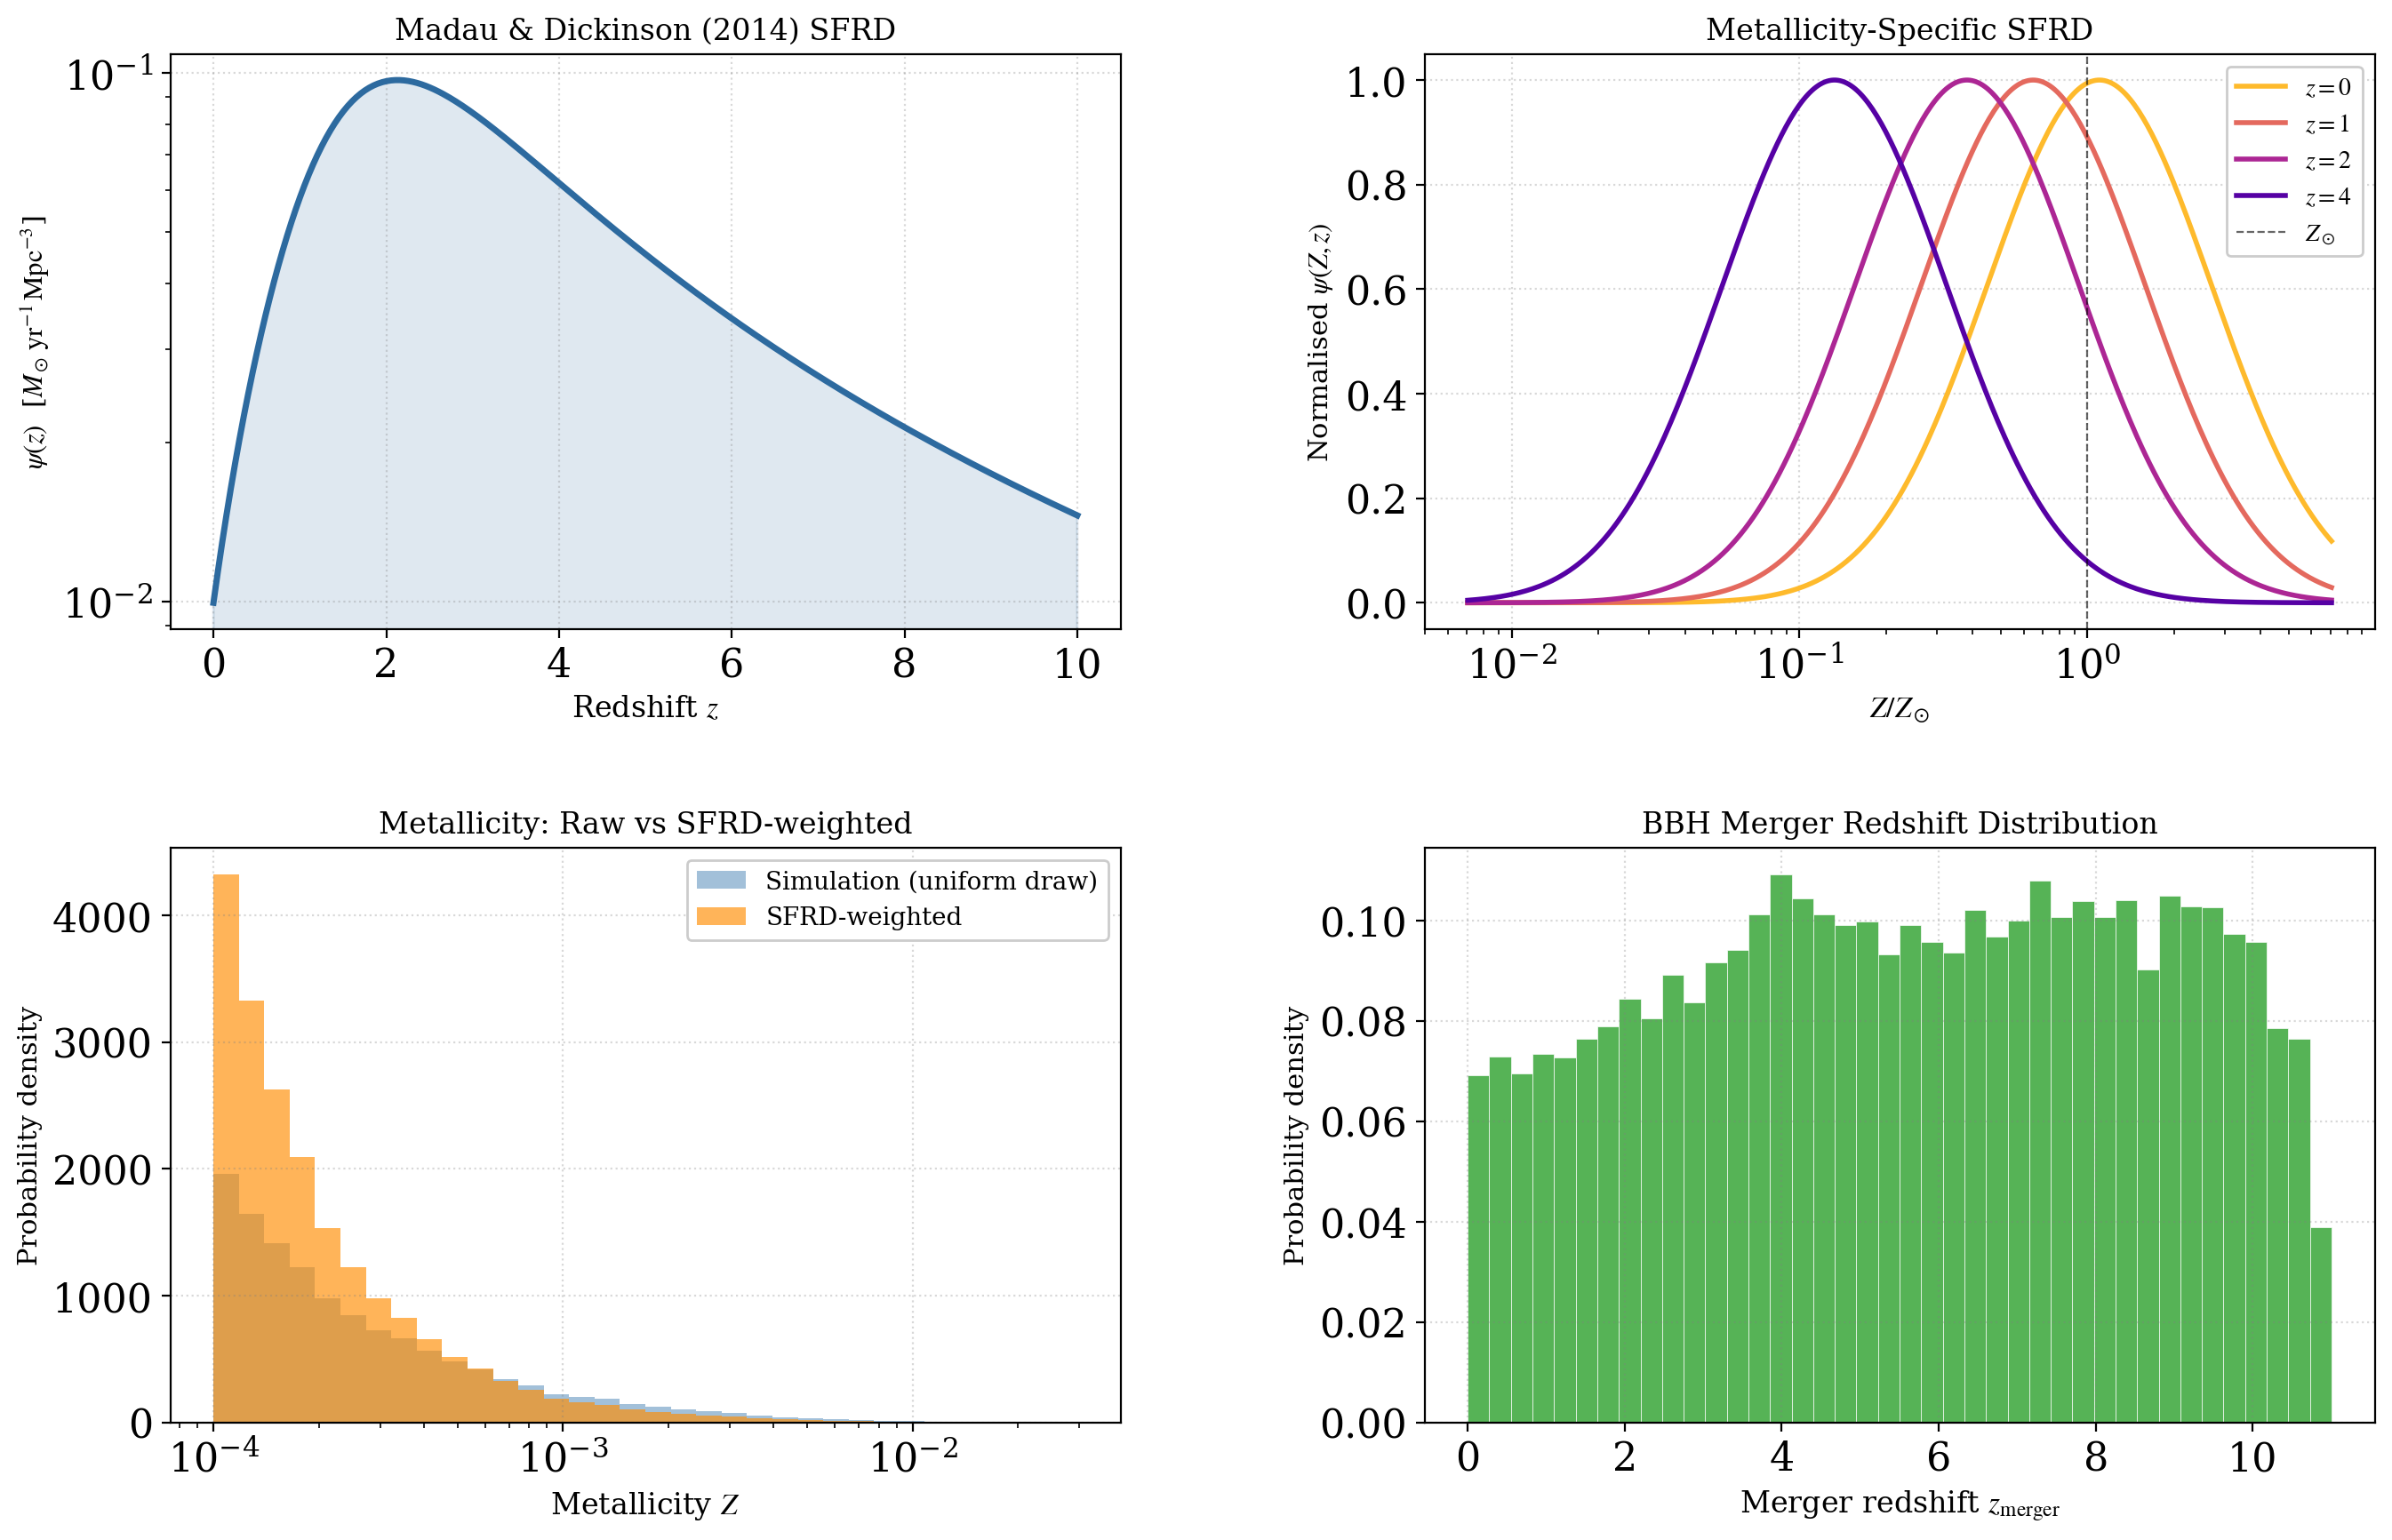

In [57]:
# ── Step 3: diagnostics ──────────────────────────────────────────────────
plot_diagnostics(df_sim, df_weighted, df_obs)
plt.show()

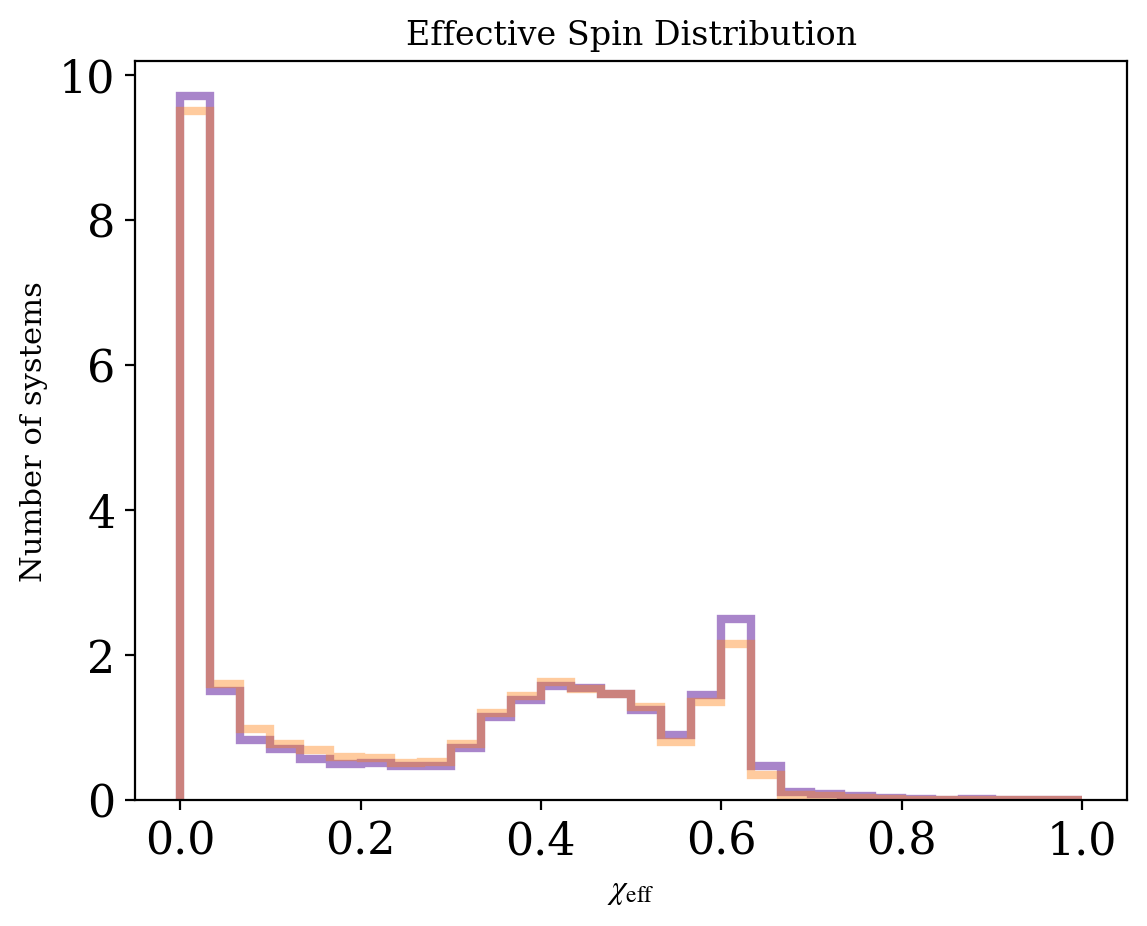

In [58]:
plt.hist(df_obs["chi_eff"], bins=30, density=True, color="#9467bd", alpha=0.8, histtype='step', lw=3)
plt.hist(df_sim["chi_eff"], bins=30, density=True, color="#ff7f0e", alpha=0.4, histtype='step', lw=3)

plt.xlabel(r"$\chi_\mathrm{eff}$", fontsize=12)
plt.ylabel("Number of systems", fontsize=11)
plt.title("Effective Spin Distribution", fontsize=12)
plt.show()